# Phase 1: single-qubit noise channels

Three textbook channels promoted from notes into `qec_project.noise.channels`:
bit-flip, phase-flip, and depolarizing. We track what each one does to the
Bloch vector and verify the depolarizing channel converges to the maximally
mixed state at $p = 3/4$ (the saturation point under the "$p/3$ per Pauli"
Kraus convention; see Nielsen & Chuang sec. 8.3.4).

All numbers below are computed live from the module.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qec_project.noise.channels import (
    apply_channel,
    bit_flip_kraus,
    depolarizing_kraus,
    is_trace_preserving,
    phase_flip_kraus,
)

SEED = 20260515
rng = np.random.default_rng(SEED)

# |+><+| is a maximally biased starting point: Bloch vector r=(1, 0, 0).
ket_plus = (1 / np.sqrt(2)) * np.array([1.0, 1.0], dtype=np.complex128)
rho_plus = np.outer(ket_plus, ket_plus.conj())

PAULI_X = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=np.complex128)
PAULI_Y = np.array([[0.0, -1.0j], [1.0j, 0.0]], dtype=np.complex128)
PAULI_Z = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=np.complex128)


def bloch_vector(rho: np.ndarray) -> np.ndarray:
    return np.array(
        [
            np.trace(PAULI_X @ rho).real,
            np.trace(PAULI_Y @ rho).real,
            np.trace(PAULI_Z @ rho).real,
        ]
    )


# Sanity: every channel we ship should be trace-preserving.
for name, ks in [
    ("bit_flip", bit_flip_kraus(0.3)),
    ("phase_flip", phase_flip_kraus(0.3)),
    ("depolarizing", depolarizing_kraus(0.3)),
]:
    assert is_trace_preserving(ks), name
print("All three channels trace-preserving at p=0.3: OK")


All three channels trace-preserving at p=0.3: OK


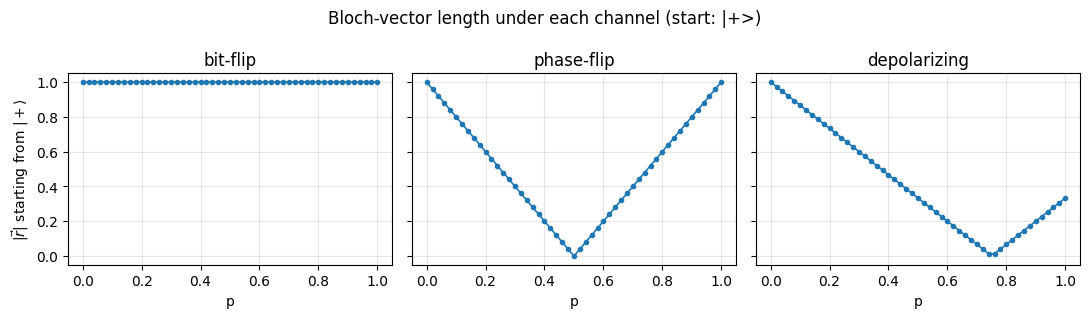

    bit-flip: r(0)=1.0000, r(1/2)=1.0000, r(3/4)=1.0000, r(1)=1.0000
  phase-flip: r(0)=1.0000, r(1/2)=0.0000, r(3/4)=0.4800, r(1)=1.0000
depolarizing: r(0)=1.0000, r(1/2)=0.3333, r(3/4)=0.0133, r(1)=0.3333


In [2]:
ps = np.linspace(0.0, 1.0, 51)
channels = {
    "bit-flip": bit_flip_kraus,
    "phase-flip": phase_flip_kraus,
    "depolarizing": depolarizing_kraus,
}

results: dict[str, np.ndarray] = {}
for name, factory in channels.items():
    rs = np.empty_like(ps)
    for i, p in enumerate(ps):
        out = apply_channel(rho_plus, factory(float(p)))
        rs[i] = np.linalg.norm(bloch_vector(out))
    results[name] = rs

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, (name, rs) in zip(axes, results.items(), strict=True):
    ax.plot(ps, rs, marker="o", markersize=3, linewidth=1.2)
    ax.set_title(name)
    ax.set_xlabel("p")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel(r"$|\vec r|$ starting from $|+\rangle$")
fig.suptitle("Bloch-vector length under each channel (start: |+>)")
fig.tight_layout()
plt.show()

# Tabulate the endpoints so the reader can see the structural difference.
for name, rs in results.items():
    print(f"{name:>12}: r(0)={rs[0]:.4f}, r(1/2)={rs[25]:.4f}, r(3/4)={rs[37]:.4f}, r(1)={rs[-1]:.4f}")


In [3]:
# At p = 3/4 the depolarizing Kraus channel sends every input to I/2.
target = 0.5 * np.eye(2, dtype=np.complex128)
out_three_quarters = apply_channel(rho_plus, depolarizing_kraus(0.75))
trace_distance = 0.5 * np.linalg.svd(out_three_quarters - target, compute_uv=False).sum()
print("output at p=3/4:")
print(np.round(out_three_quarters, 6))
print(f"trace distance to I/2: {trace_distance:.2e}")


output at p=3/4:
[[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
trace distance to I/2: 1.11e-16


## Takeaway

Bit-flip and phase-flip contract the Bloch vector along a single axis, so an
$|+\rangle$ input keeps unit length under phase-flip (it lies on the $X$
axis, untouched by $Z$-error rotations) and decays linearly to zero under
bit-flip at $p = 1/2$. The depolarizing channel contracts isotropically and
reaches the maximally mixed state $I/2$ at $p = 3/4$ under the $p/3$-per-Pauli
Kraus convention.
